# Project: Video Game Sales Data Analysis

# 1) Cleaning

In [1]:
#installing packages
!pip install numpy pandas matplotlib seaborn scipy scikit-learn

In [2]:
#importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#loading the data
df = pd.read_csv('vgchartz-2024.csv')
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


I noticed there are multiple entries for the same game, due to cross-platform releases, and so this is what I wanted to look into next.

In [4]:
df['title'].value_counts()

title
Plants vs. Zombies                  17
Pac-Man                             16
Monopoly                            15
Doom                                14
Double Dragon                       14
                                    ..
Bakegyamon: Ayakashi Fighting        1
Avatar Showdown                      1
Avatar Fighter Online                1
Avatar Fighter                       1
Yurukill: The Calumniation Games     1
Name: count, Length: 39798, dtype: int64

In particular, Plants vs. Zombies seems to be the game on the highest number of platforms, so this is worth looking into more.

In [5]:
df[df['title'] == 'Plants vs. Zombies'].sort_values('console')

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
36841,/games/boxart/default.jpg,Plants vs. Zombies,And,Misc,Electronic Arts,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,2011-12-14,NaN
1292,/games/boxart/full_plants-vs-zombies_140Americ...,Plants vs. Zombies,DS,Strategy,PopCap Games,PopCap Games,8.1,1.11,0.90,NaN,0.13,0.09,2011-01-18,NaN
36839,/games/boxart/default.jpg,Plants vs. Zombies,DS,Misc,PopCap Games,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,2011-01-18,NaN
36843,/games/boxart/default.jpg,Plants vs. Zombies,DSi,Misc,PopCap Games,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,2011-03-14,NaN
62533,/games/boxart/full_plants-vs-zombies_451Americ...,Plants vs. Zombies,DSiW,Strategy,PopCap Games,PopCap Games,NaN,NaN,NaN,NaN,NaN,NaN,2011-03-14,NaN
36840,/games/boxart/default.jpg,Plants vs. Zombies,OSX,Misc,PopCap Games,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,2009-03-05,NaN
36844,/games/boxart/default.jpg,Plants vs. Zombies,OSX,Misc,PopCap Games,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,2009-05-05,NaN
60934,/games/boxart/full_1604043AmericaFrontccc.jpg,Plants vs. Zombies,PC,Strategy,PopCap Games,PopCap Games,9.0,NaN,NaN,NaN,NaN,NaN,2009-05-05,NaN
6823,/games/boxart/full_plants-vs-zombies_181Americ...,Plants vs. Zombies,PS3,Strategy,PopCap Games,PopCap,NaN,0.21,0.18,NaN,NaN,0.03,2011-11-15,NaN
36838,/games/boxart/default.jpg,Plants vs. Zombies,PS3,Misc,Sony Computer Entertainment,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,2011-02-08,NaN


From this evidence, strategies to clean the data emerge. The predominant idea would be to combine each entry for a game into a single row, with sales accumulating, critic scores being averaged and the earliest release date being used. However, following this idea would lead to a loss in information relating to the console launched. This requires further investigation.

In [6]:
all_duplicates = df[df.duplicated(keep=False)]
print(all_duplicates)

Empty DataFrame
Columns: [img, title, console, genre, publisher, developer, critic_score, total_sales, na_sales, jp_sales, pal_sales, other_sales, release_date, last_update]
Index: []


A quick check confirms there are no duplicated rows in this data frame.

Next, I will create a new data frame where each game is collapsed into one row, taking score averaged across all platforms, weighted by the number of sales for accuracy. In addition, I will log all consoles of release as a list as to not lose any information, and take the earliest release date and latest update date.

In [7]:
#Date correctly formatted
df['release_date'] = pd.to_datetime(df['release_date'])
df['last_update'] = pd.to_datetime(df['last_update'])

#Define function for critic score weighting
def weighted_critic_score(group):
    valid = group.dropna(subset=['critic_score', 'total_sales'])
    if valid.empty or valid['total_sales'].sum() == 0:
        return group['critic_score'].mean()
    return np.average(valid['critic_score'], weights=valid['total_sales'])

#Apply function
weighted_scores = df.groupby('title').apply(weighted_critic_score).reset_index(name='critic_score')

#Aggregation dictionary
agg_dict = {
    'console': lambda x: list(x.unique()),
    'genre': lambda x: list(x.unique()),
    'publisher': lambda x: list(x.unique()),
    'developer': lambda x: list(x.unique()),
    'total_sales': 'sum',
    'na_sales': 'sum',
    'jp_sales': 'sum',
    'pal_sales': 'sum',
    'other_sales': 'sum',
    'release_date': 'min',
    'last_update': 'max'}

#Perform aggregation
df2 = df.groupby('title', as_index=False).agg(agg_dict)

#Add in the weighted scores column
df2 = df2.drop(columns=['critic_score'], errors='ignore').merge(weighted_scores, on='title')

In [8]:
df2[df2['title'] == 'Plants vs. Zombies']

,title,console,genre,publisher,developer,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,critic_score
25192,Plants vs. Zombies,"[DS, X360, PS3, PSV, OSX, And, DSi, WinP, PC, ...","[Strategy, Misc]","[PopCap Games, Sony Computer Entertainment, El...","[PopCap Games, PopCap, Unknown]",1.59,1.32,0.0,0.13,0.14,2009-03-05,NaT,8.256522


We can see the now cleaned data entry for Plants vs. Zombies!

In [9]:
df2.sort_values('critic_score',ascending=False).head(10)

,title,console,genre,publisher,developer,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,critic_score
11649,Final Fantasy II,"[NES, WS, GBA, PSP, SNES, All, VC, PS, PSN, PC]","[Role-Playing, Misc]","[Square, Nintendo, Square Enix, Unknown]","[Square, SquareSoft, Unknown, Square Enix]",1.01,0.00,1.01,0.00,0.00,1988-12-17,2024-01-24,10.000000
27027,Red Dead Redemption: Undead Nightmare,"[PS3, X360, PSN, XBL, All]","[Action, Action-Adventure]",[Rockstar Games],[Rockstar San Diego],2.29,1.08,0.08,0.83,0.29,2010-10-26,2020-10-30,10.000000
12506,Fusion: Genesis,[XBL],[Shooter],[Microsoft],[Starfire Studios],0.00,0.00,0.00,0.00,0.00,2011-11-09,NaT,10.000000
32411,Super Mario Kart,"[SNES, VC]",[Racing],[Nintendo],[Nintendo EAD],0.00,0.00,0.00,0.00,0.00,1992-09-01,NaT,10.000000
11727,Final Fight,"[Series, SNES, VC, ACPC, GBA, SCD, ZXS, C64, A...","[Action, Fighting, Misc]","[Capcom, U.S. Gold, Sega]","[Capcom, Unknown]",0.00,0.00,0.00,0.00,0.00,1989-12-01,2020-02-03,10.000000
35187,The gamrReview Test Game,[NES],[Fighting],[Unknown],[VGChartz],0.00,0.00,0.00,0.00,0.00,1994-01-13,NaT,10.000000
34501,The Legend of Zelda Collector's Edition,[GC],[Adventure],[Nintendo],[Nintendo Software Technology Corporation],0.00,0.00,0.00,0.00,0.00,2003-11-17,NaT,10.000000
13719,Grand Theft Auto IV,"[X360, PS3, PC, XBL, All]","[Action, Action-Adventure]",[Rockstar Games],"[Rockstar North, Rockstar Toronto]",22.53,11.60,0.58,7.64,2.72,2008-04-29,2020-10-13,9.969108
34504,The Legend of Zelda: Breath of the Wild,"[All, NS, WiiU]",[Action-Adventure],[Nintendo],"[Nintendo, Nintendo EPD]",0.00,0.00,0.00,0.00,0.00,2017-03-03,2023-02-07,9.950000
32418,Super Mario Odyssey,[NS],[Platform],[Nintendo],[Nintendo EPD],0.00,0.00,0.00,0.00,0.00,2017-10-27,2018-11-19,9.900000


After looking at the top games by critic score, as someone with a lot of knowledge of the games industry, it is immediately clear that this data is no longer accurate. This list does not exactly match the top games on metacritic.com. For the puposes of this project, I will continue to analise this data set (almost as if it were fictitious) but I thought it is important to note if I intended for this analysis to result in factual industry insight, I would stop using this data at this point.

I now want to zoom in on the missing values in this data set.

In [10]:
#Replace zeros
df2 = df2.replace(0, np.nan)

#Finding missing values
print(len(df2), 'data points')
print(df2.isna().sum())

39798 data points
title               0
console             0
genre               0
publisher           0
developer           0
total_sales     27759
na_sales        31972
jp_sales        34419
pal_sales       33070
other_sales     33321
release_date     2911
last_update     30715
critic_score    35080
dtype: int64


We will remove rows with missing values under sales, this is the main focus of this project and so data without these values is not of use.

In [11]:
#Remove missing sales values
df3 = df2.dropna(subset=["total_sales"])

print('Now working with', len(df3), 'data points')
print(df3.isna().sum())

Now working with 12039 data points
title              0
console            0
genre              0
publisher          0
developer          0
total_sales        0
na_sales        4213
jp_sales        6660
pal_sales       5311
other_sales     5562
release_date      32
last_update     9256
critic_score    9086
dtype: int64


I will run a quick check to see if there are missing values under total yet values in regional sales.

In [12]:
regional_cols = ["na_sales", "jp_sales", "pal_sales", "other_sales"]
missing_total = df2["total_sales"].isna()
has_regional_value = df2[regional_cols].notna().any(axis=1)
matching_rows = df2[missing_total & has_regional_value]

print(f"Found {len(matching_rows)} matching rows")

Found 0 matching rows


There are no such rows so we can proceed with df3. I am reasonably happy with the data now and will begin EDA.

# 2) EDA

I will begin by generating a few interesting plots.

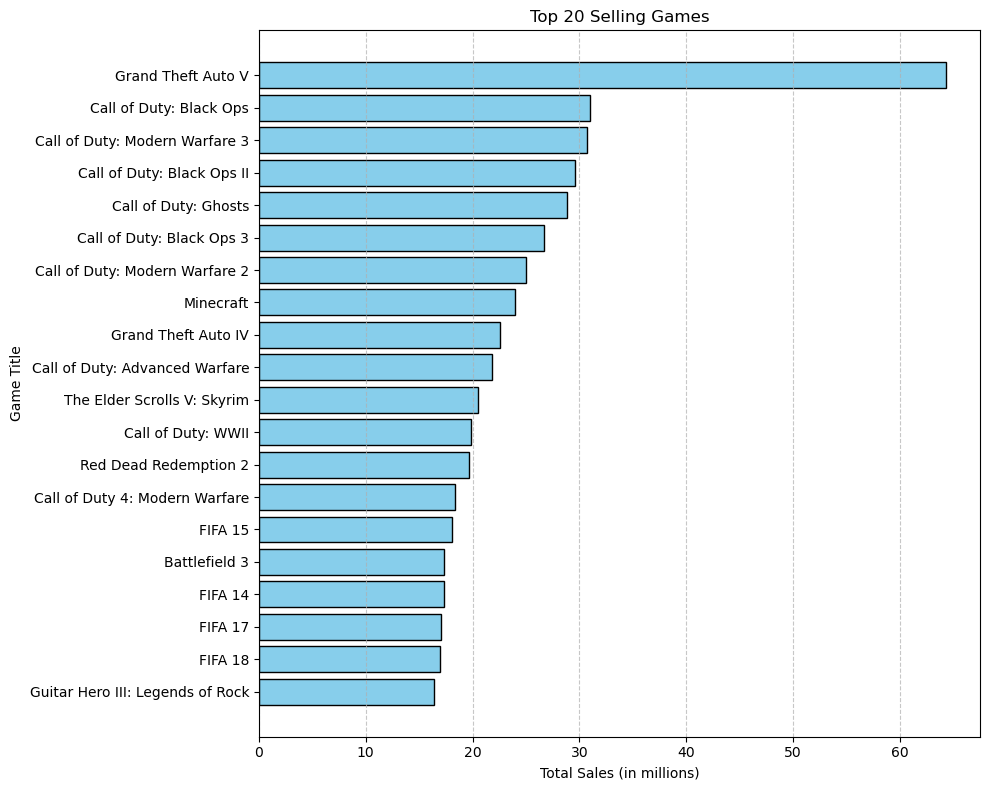

In [13]:
#Top 20 best selling games

top20 = df3.nlargest(20, "total_sales").sort_values(
    by="total_sales", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top20["title"], top20["total_sales"], color="skyblue", edgecolor="black")

plt.xlabel("Total Sales (in millions)")
plt.ylabel("Game Title")
plt.title("Top 20 Selling Games")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()

C:\Users\alexm\AppData\Local\Temp\ipykernel_128716\2100258085.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["year"] = df3["release_date"].dt.year


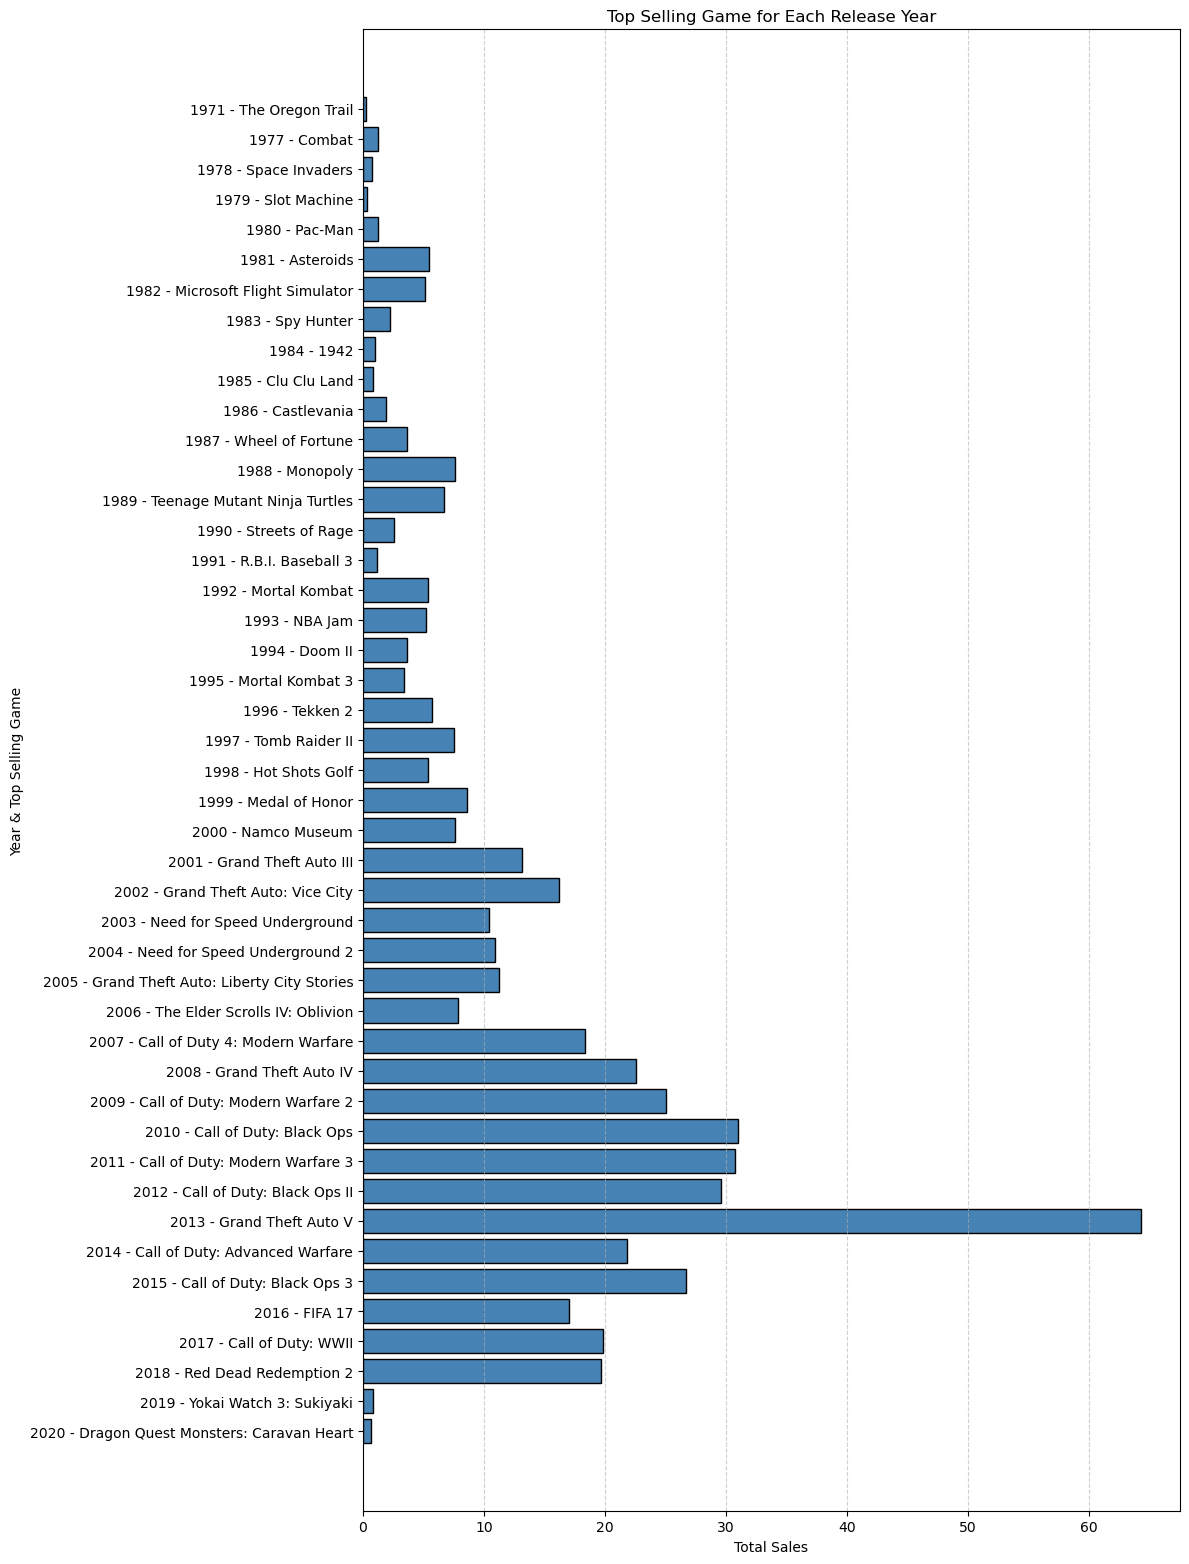

In [14]:
#Plot of top selling game each release year

#Create year only column
df3["year"] = df3["release_date"].dt.year

#Create new df for the top games each year
top_games_per_year = (
    df3.sort_values(by='total_sales', ascending=False)
    .groupby('year', as_index=False)
    .first()
    .sort_values(by='year'))

#Convert to int
top_games_per_year['year'] = top_games_per_year['year'].astype(int)

#Display label
top_games_per_year["label"] = (
    top_games_per_year['year'].astype(str)
    + " - "
    + top_games_per_year['title'])

#Plot
plt.figure(figsize=(12, max(6, len(top_games_per_year) * 0.35)))
plt.barh(
    top_games_per_year["label"],
    top_games_per_year['total_sales'],
    color="steelblue",
    edgecolor="black",)
plt.gca().invert_yaxis()

#Label plot
plt.xlabel("Total Sales")
plt.ylabel("Year & Top Selling Game")
plt.title("Top Selling Game for Each Release Year")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

This plot hints to the game industry growing substantially during the 2000s.

The next plot to look at would be the relationship between popularity (sales) and critic score. We will need to take a subset of the data as there are only a few games with a recorded critic score.

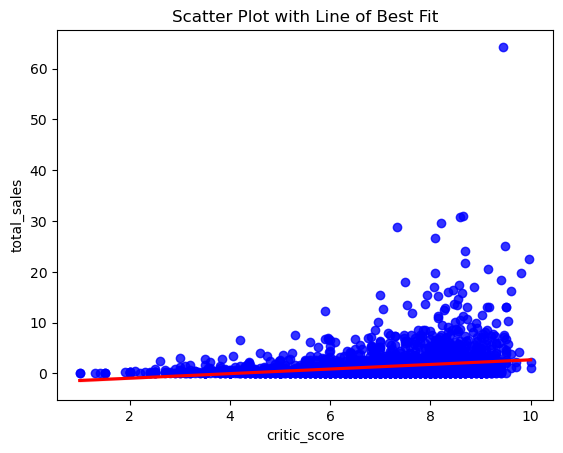

In [15]:
df4 = df3.dropna(subset=["critic_score"])

sns.regplot(
    data=df4,
    x="critic_score",
    y="total_sales",
    scatter_kws={"color": "blue"},
    line_kws={"color": "red"})

plt.title("Scatter Plot with Line of Best Fit")
plt.show()

C:\Users\alexm\AppData\Local\Temp\ipykernel_128716\2093558283.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['log_total_sales'] = np.log(df4['total_sales'])


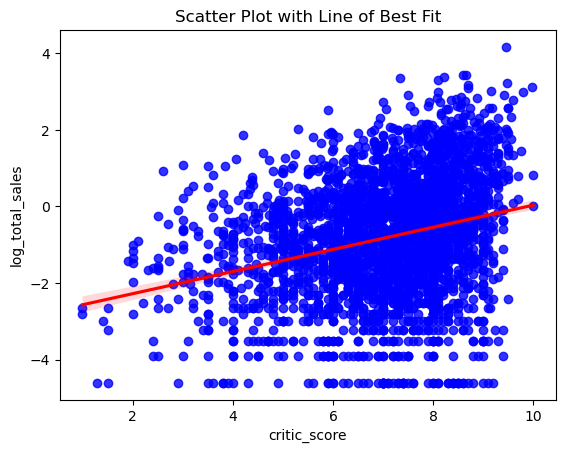

In [16]:
df4['log_total_sales'] = np.log(df4['total_sales'])

sns.regplot(
    data=df4,
    x="critic_score",
    y="log_total_sales",
    scatter_kws={"color": "blue"},
    line_kws={"color": "red"})

plt.title("Scatter Plot with Line of Best Fit")
plt.show()

By taking the log of total sales it becomes more clear that there appears to be a correlation between critic score and total sales, that being, games with higher critic scores tend to sell more. We cannot tell which way round this relationship is however. Could it be that a great score makes games more appealing and boosts sales or do popular games tend to lead to favourable reviews to appease lots of people.

Next, it is a good idea to get more insight into each column before I start the main analysis of the project.

In [17]:
df3.describe()

,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,critic_score,year
count,12039.000000,7826.000000,5379.000000,6728.000000,6477.000000,12007,2783,2953.000000,12007.000000
mean,0.548709,0.427488,0.127894,0.284903,0.100528,2007-03-23 06:08:32.700924416,2019-05-06 20:22:09.787998464,7.034529,2006.673357
min,0.010000,0.010000,0.010000,0.010000,0.010000,1971-12-03 00:00:00,2017-12-29 00:00:00,1.000000,1971.000000
25%,0.050000,0.060000,0.020000,0.030000,0.010000,2003-05-06 00:00:00,2018-07-13 00:00:00,6.276471,2003.000000
50%,0.150000,0.150000,0.060000,0.070000,0.030000,2008-02-28 00:00:00,2018-11-18 00:00:00,7.300000,2008.000000
75%,0.450000,0.390000,0.150000,0.220000,0.070000,2011-04-14 00:00:00,2020-02-26 00:00:00,8.100000,2011.000000
max,64.290000,26.190000,4.260000,28.140000,8.320000,2020-12-31 00:00:00,2024-01-24 00:00:00,10.000000,2020.000000
std,1.577087,0.964935,0.199882,0.827279,0.277296,NaN,NaN,1.468785,6.625579


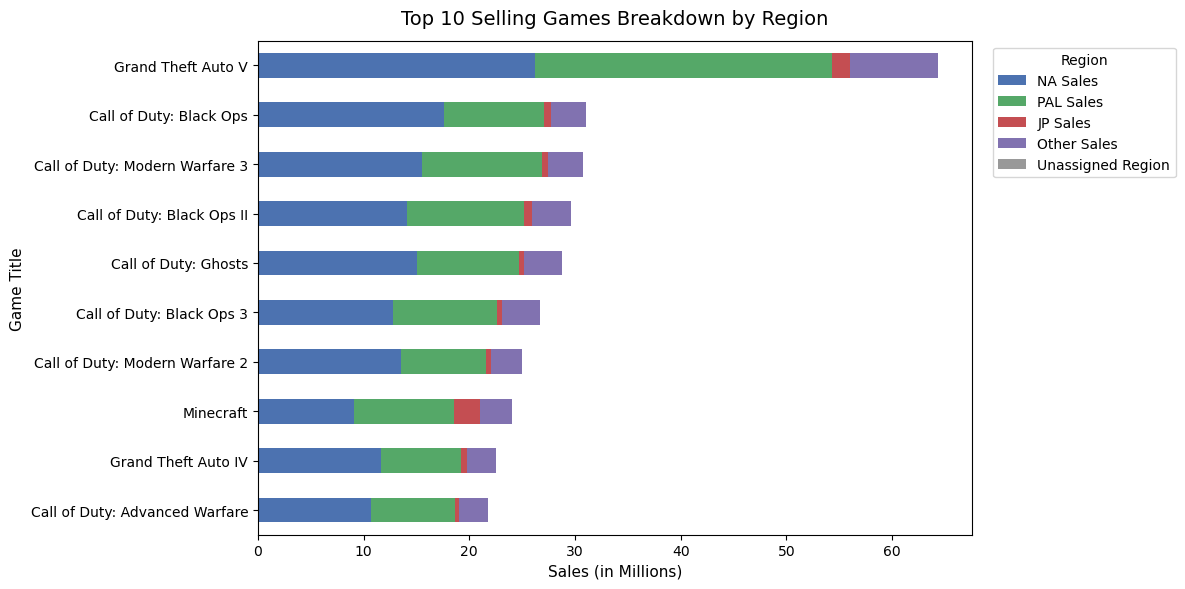

In [41]:
def create_top10_plot(input, plot_title):
#Get top10 games
    top10 = df3.nlargest(10, input).copy()
    
#Replace NAs with 0
    regional_cols = ['na_sales', 'pal_sales', 'jp_sales', 'other_sales']
    top10[regional_cols] = top10[regional_cols].fillna(0)

#Account for missing regional sales data
    known_regional_sum = top10[regional_cols].sum(axis=1)
    top10['unassigned_sales'] = (top10['total_sales'] - known_regional_sum).clip(lower=0)

#Prepare data
    plot_cols = [
        'na_sales',
        'pal_sales',
        'jp_sales',
        'other_sales',
        'unassigned_sales']
    plot_df = top10.set_index('title')[plot_cols]
    plot_df.columns = [
        'NA Sales',
        'PAL Sales',
        'JP Sales',
        'Other Sales',
        'Unassigned Region']

#Generate plot
    ax = plot_df.plot(
        kind='barh',
        stacked=True,
        figsize=(12, 6),
        color=['#4C72B0', '#55A868', '#C44E52', '#8172B0', '#999999'])

    plt.gca().invert_yaxis()  # Keeps the #1 top game at the top of the chart
    plt.title(plot_title, fontsize=14, pad=12)
    plt.xlabel('Sales (in Millions)', fontsize=11)
    plt.ylabel('Game Title', fontsize=11)
    plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    return plt.show()

create_top10_plot('total_sales', 'Top 10 Selling Games Breakdown by Region')

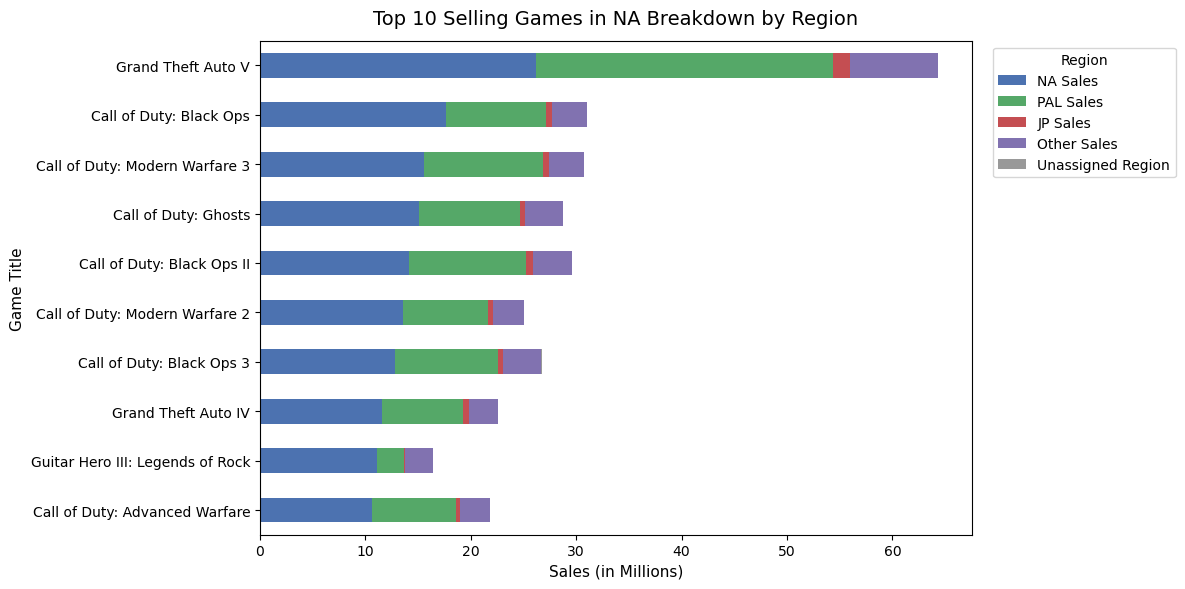

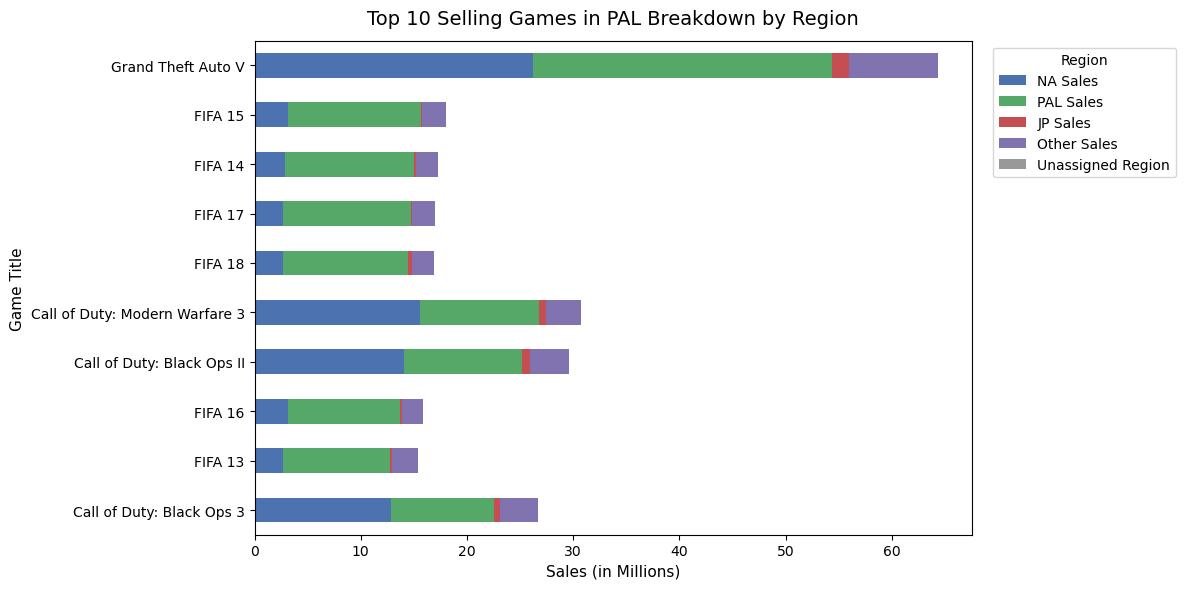

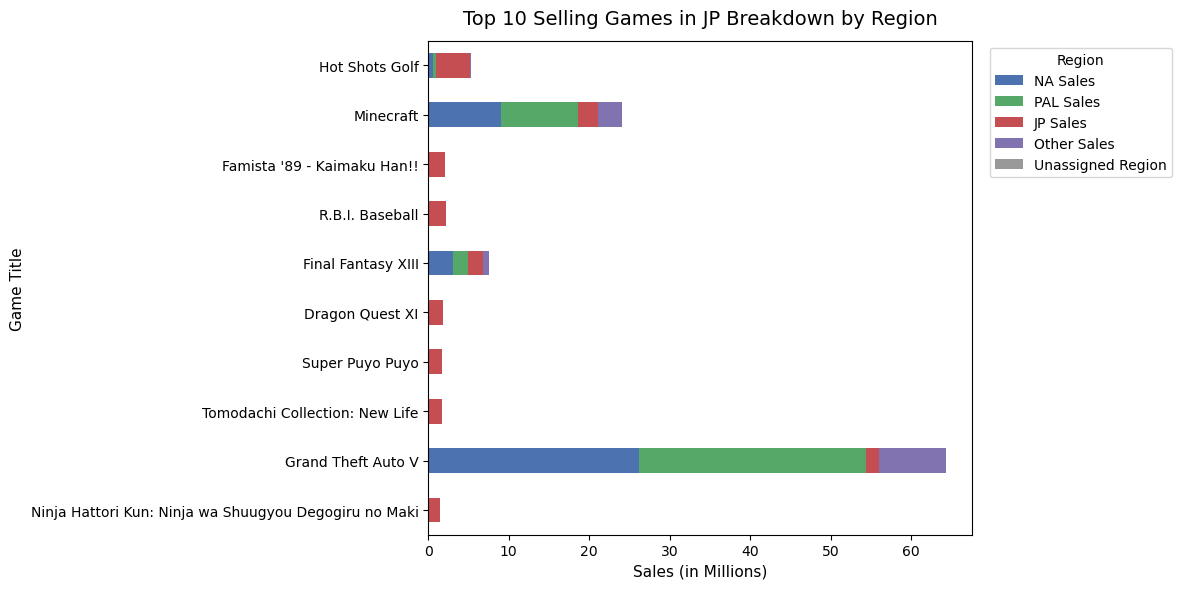

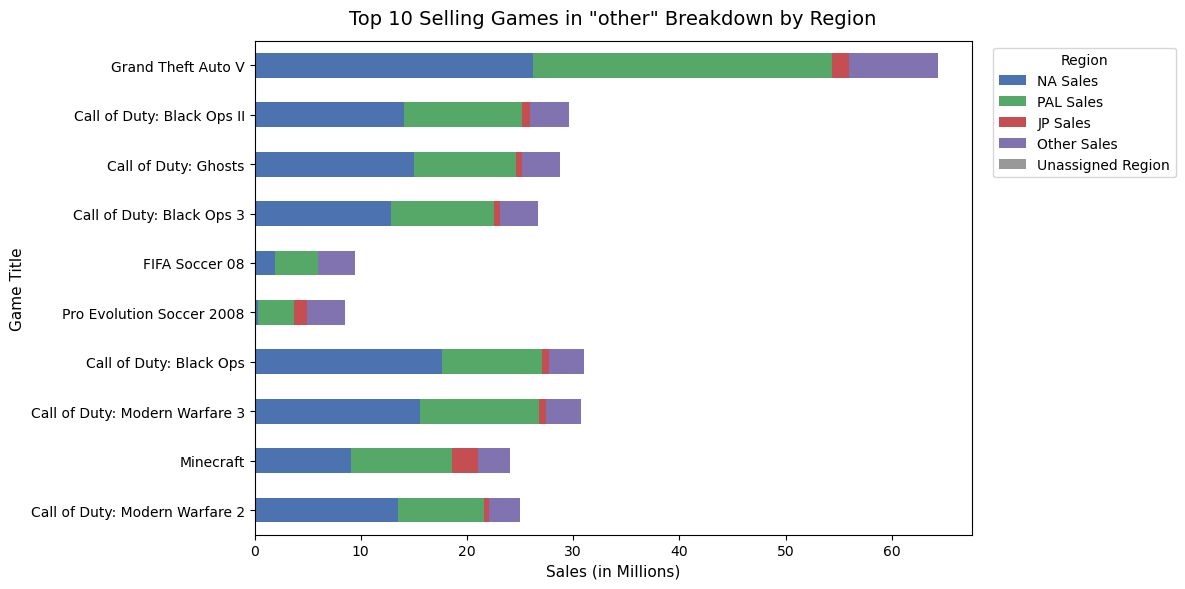

In [19]:
create_top10_plot('na_sales', 'Top 10 Selling Games in NA Breakdown by Region')
create_top10_plot('pal_sales', 'Top 10 Selling Games in PAL Breakdown by Region')
create_top10_plot('jp_sales', 'Top 10 Selling Games in JP Breakdown by Region')
create_top10_plot('other_sales', 'Top 10 Selling Games in "other" Breakdown by Region')

North America seems to match the trends of the entire data set whereas PAL and Japan have less popular games globally which sell high in their respective regions. This could be a bias in the data set towards America or a trend of the game industry as a whole- what sells well in America sells well globally!

Another thing to focus on is sales across years, this can be done with a simple plot.

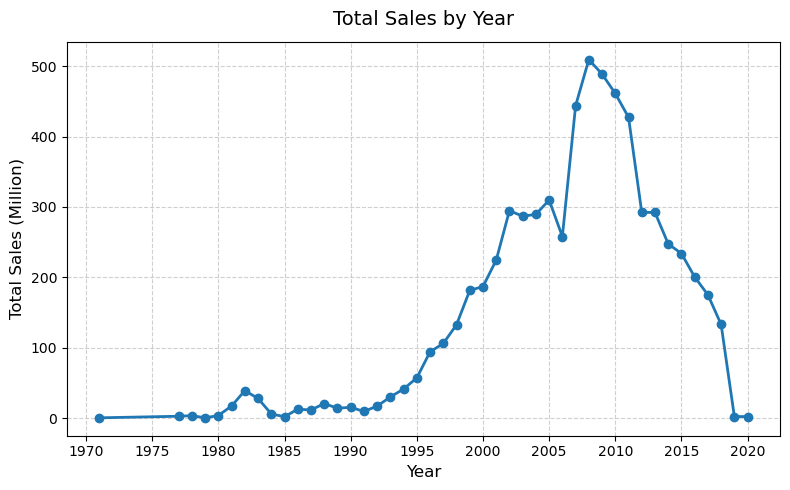

In [20]:
#Sum sales across years
yearly_sales = df3.groupby('year')['total_sales'].sum().reset_index()

#reate the line graph
plt.figure(figsize=(8, 5))
plt.plot(yearly_sales['year'], yearly_sales['total_sales'], marker='o', color='#1f77b4', linewidth=2)

#Formatting
plt.title('Total Sales by Year', fontsize=14, pad=12)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales (Million)', fontsize=12)
min_year = int(yearly_sales['year'].min())
max_year = int(yearly_sales['year'].max())
plt.xticks(range(min_year-1, max_year + 1, 5))

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Now we can also zoom in on aspects such as console, developer and genre and how they influence sales and critic score. We will need to look at the data frame before we grouped by game title in order to generate more accuracte statistics.

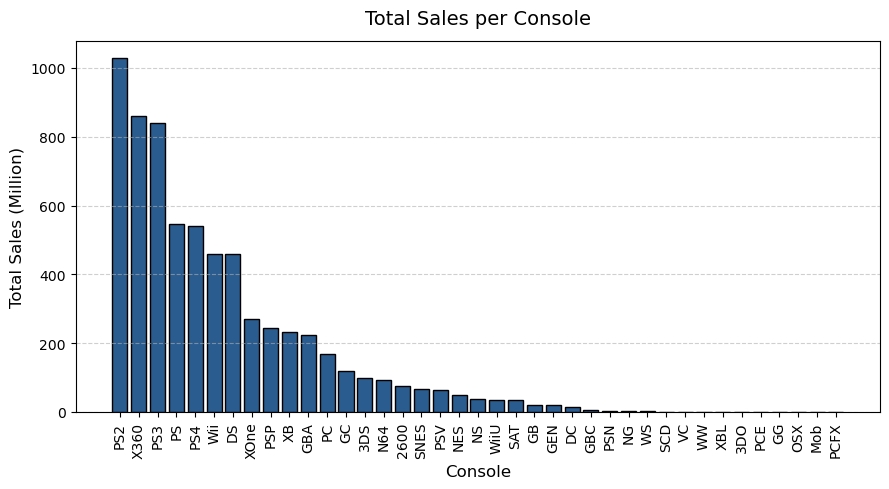

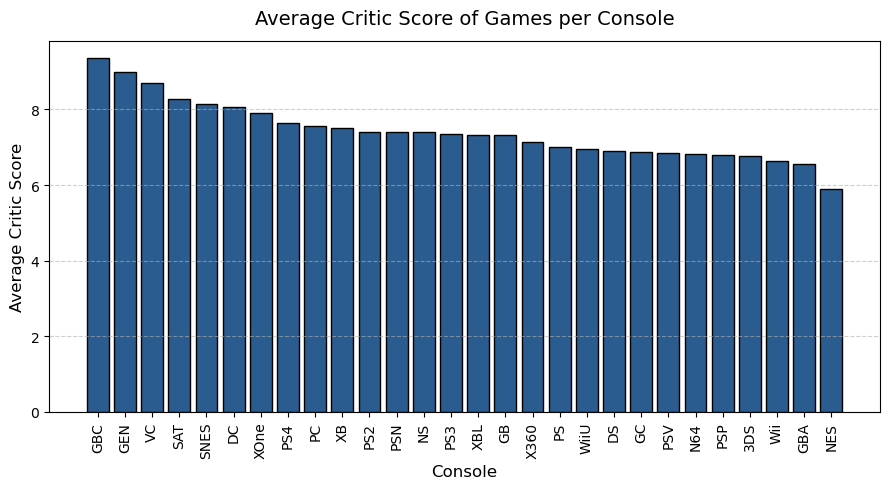

In [21]:
df5 = df.dropna(subset=['total_sales'])

#Group
console_sales = (
    df5.groupby('console')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index())

#Plot ordered bar chart
plt.figure(figsize=(9, 5))
bars = plt.bar(
    console_sales['console'], 
    console_sales['total_sales'], 
    color='#2b5c8f', 
    edgecolor='black')

#Formatting
plt.title('Total Sales per Console', fontsize=14, pad=12)
plt.xlabel('Console', fontsize=12)
plt.xticks(rotation=90)
plt.ylabel('Total Sales (Million)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

df6 = df5.dropna(subset=['critic_score'])

#Group
console_critic = (
    df6.groupby('console')['critic_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index())

#Plot ordered bar chart
plt.figure(figsize=(9, 5))
bars = plt.bar(
    console_critic['console'], 
    console_critic['critic_score'], 
    color='#2b5c8f', 
    edgecolor='black')

#Formatting
plt.title('Average Critic Score of Games per Console', fontsize=14, pad=12)
plt.xlabel('Console', fontsize=12)
plt.xticks(rotation=90)
plt.ylabel('Average Critic Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

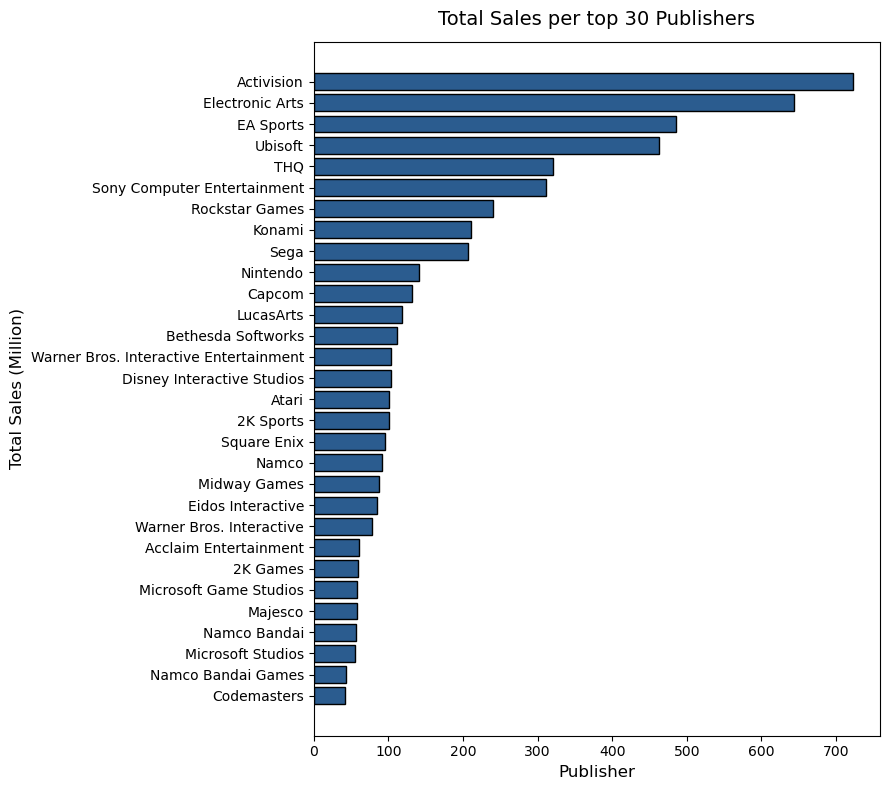

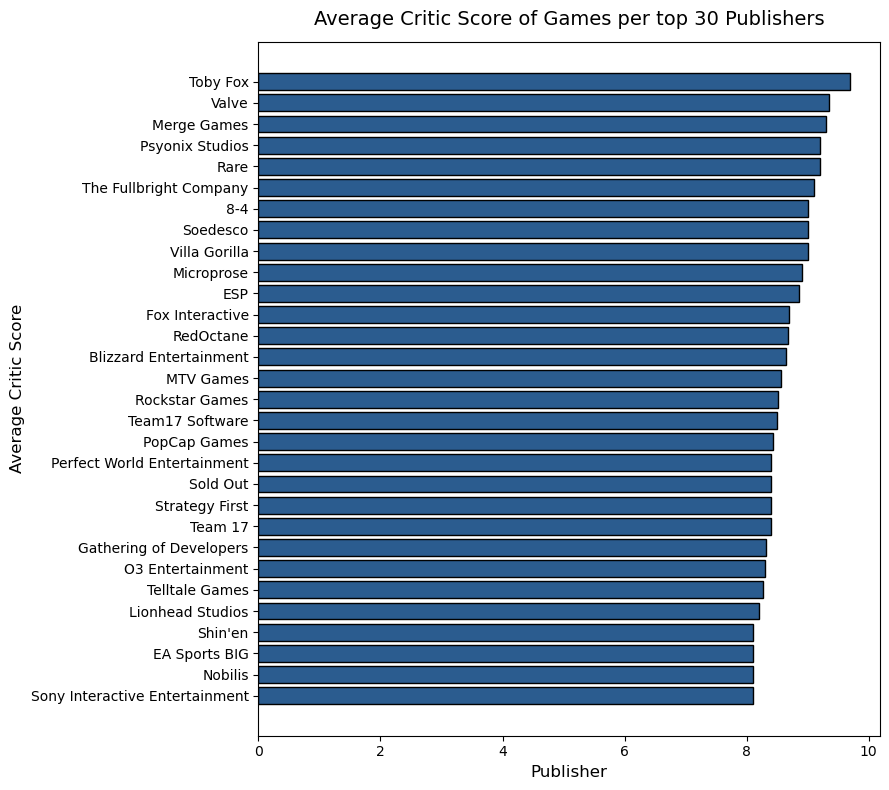

In [22]:
#Group
publisher_sales = (
    df5.groupby('publisher')['total_sales']
    .sum()
    .nlargest(30)
    .sort_values(ascending=True)
    .reset_index())

#Plot ordered bar chart
plt.figure(figsize=(9, 8))
bars = plt.barh(
    publisher_sales['publisher'], 
    publisher_sales['total_sales'], 
    color='#2b5c8f', 
    edgecolor='black')

#Formatting
plt.title('Total Sales per top 30 Publishers', fontsize=14, pad=12)
plt.xlabel('Publisher', fontsize=12)
plt.ylabel('Total Sales (Million)', fontsize=12)

plt.tight_layout()
plt.show()

#Group
publisher_critic = (
    df6.groupby('publisher')['critic_score']
    .mean()
    .nlargest(30)
    .sort_values(ascending=True)
    .reset_index())

#Plot ordered bar chart
plt.figure(figsize=(9, 8))
bars = plt.barh(
    publisher_critic['publisher'], 
    publisher_critic['critic_score'], 
    color='#2b5c8f', 
    edgecolor='black')

#Formatting
plt.title('Average Critic Score of Games per top 30 Publishers', fontsize=14, pad=12)
plt.xlabel('Publisher', fontsize=12)
plt.ylabel('Average Critic Score', fontsize=12)

plt.tight_layout()
plt.show()

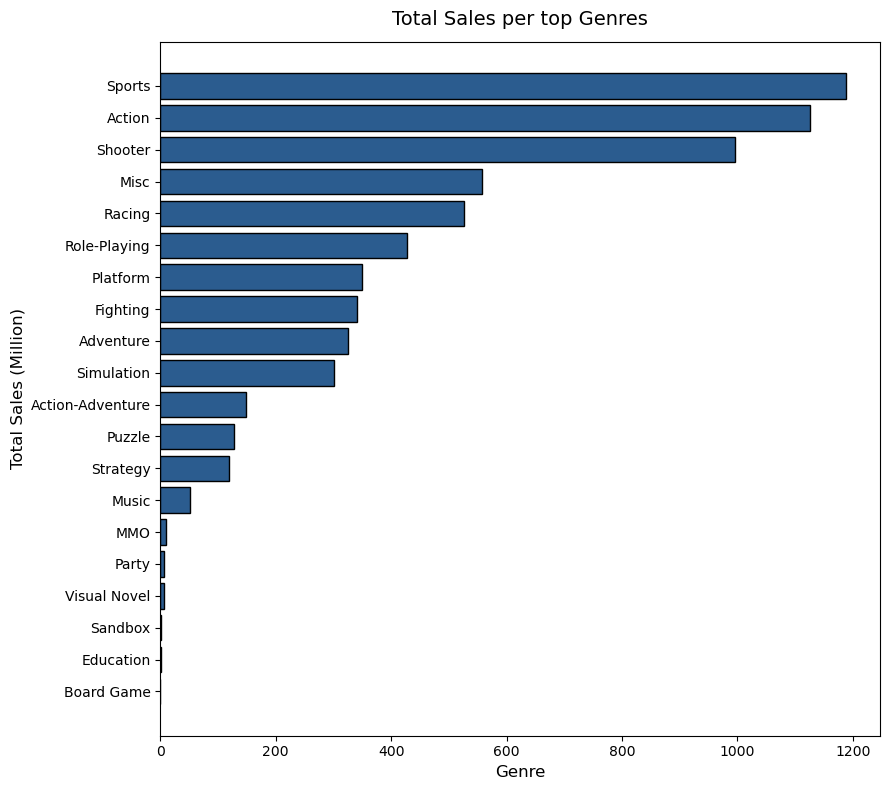

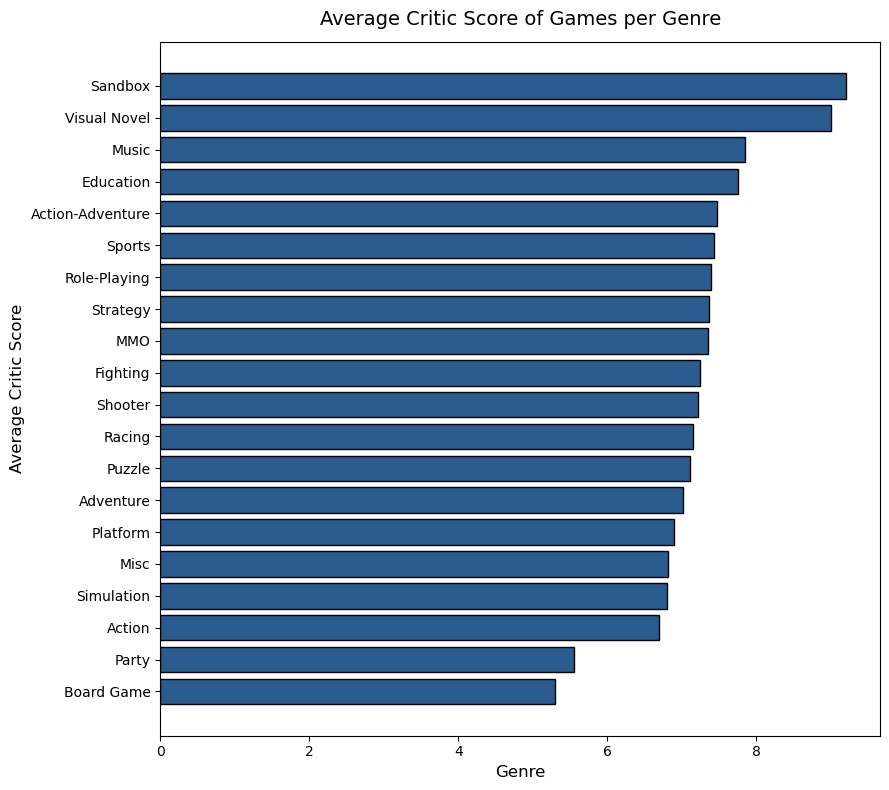

In [23]:
#Group
genre_sales = (
    df5.groupby('genre')['total_sales']
    .sum()
    .sort_values(ascending=True)
    .reset_index())

#Plot ordered bar chart
plt.figure(figsize=(9, 8))
bars = plt.barh(
    genre_sales['genre'], 
    genre_sales['total_sales'], 
    color='#2b5c8f', 
    edgecolor='black')

#Formatting
plt.title('Total Sales per top Genres', fontsize=14, pad=12)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Total Sales (Million)', fontsize=12)

plt.tight_layout()
plt.show()

#Group
genre_critic = (
    df6.groupby('genre')['critic_score']
    .mean()
    .sort_values(ascending=True)
    .reset_index())

#Plot ordered bar chart
plt.figure(figsize=(9, 8))
bars = plt.barh(
    genre_critic['genre'], 
    genre_critic['critic_score'], 
    color='#2b5c8f', 
    edgecolor='black')

#Formatting
plt.title('Average Critic Score of Games per Genre', fontsize=14, pad=12)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Average Critic Score', fontsize=12)

plt.tight_layout()
plt.show()

# Main Analysis

## The Relationship Between Sales and Critic Score

In my EDA, I have seen that there is a correlation between sales and critic score, yet at the same time, the best-selling categories within genre, console and publisher do not align with the variable with the highest critic score on average for each.

I will investigate this further. We first return to the correlation graph.

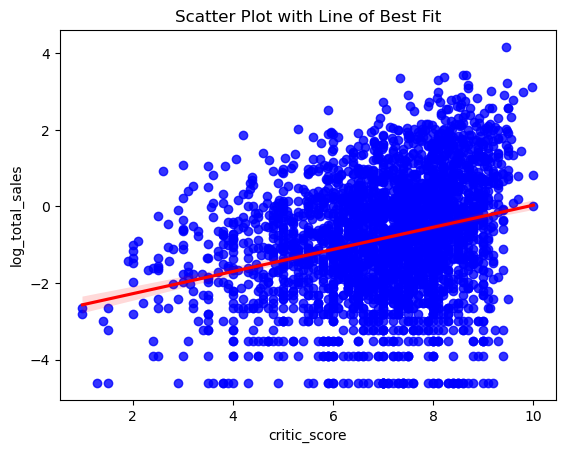

In [31]:
sns.regplot(
    data=df4,
    x="critic_score",
    y="log_total_sales",
    scatter_kws={"color": "blue"},
    line_kws={"color": "red"})

plt.title("Scatter Plot with Line of Best Fit")
plt.show()

In [33]:
#Calculating correlation coefficient
from scipy import stats
stats.pearsonr(df4['critic_score'],df4['log_total_sales'])

PearsonRResult(statistic=0.274697115307051, pvalue=2.8229003679566607e-52)

From the Pearson R test, it is clear that the correlation here is positive and relatively weak, only scoring 0.27 (no correlation being 0 and complete correlation being 1). However, the p-value, which is <<<0.05, tells us that although the correlation is weak, it is statistically significant and not the result of random noise.

I want to now zoom in on sections of the data that seem to defy this trend based on the final plots of the EDA. To begin with, sandbox was the highest-scoring genre yet had one of the lowest sales overall.

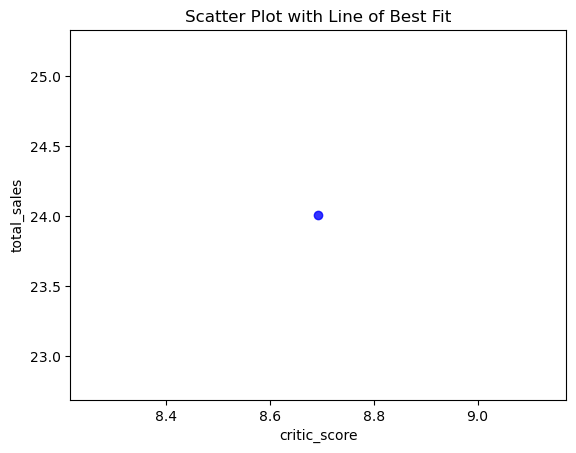

In [39]:
df_sandbox = df4[df4['genre'].apply(
    lambda x: 'Sandbox' in x if isinstance(x, (list, str, np.ndarray)) else False)]

sns.regplot(
    data=df_sandbox,
    x="critic_score",
    y="total_sales",
    scatter_kws={"color": "blue"},
    line_kws={"color": "red"})

plt.title("Scatter Plot with Line of Best Fit")
plt.show()

This plot excelently displays why we are seeing the disparity here, it is simply from a lack of data points.

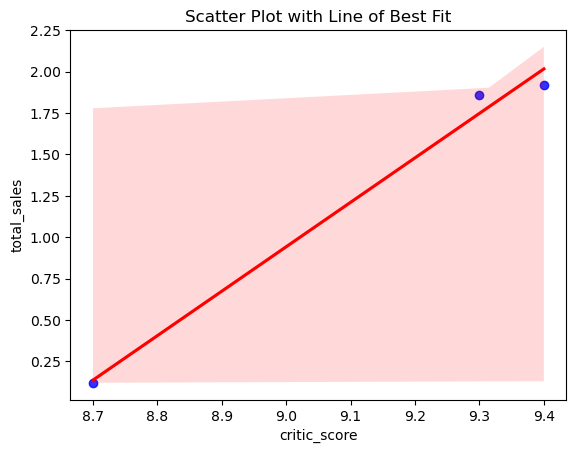

In [40]:
df_gbc = df4[df4['console'].apply(
    lambda x: 'GBC' in x if isinstance(x, (list, str, np.ndarray)) else False)]

sns.regplot(
    data=df_gbc,
    x="critic_score",
    y="total_sales",
    scatter_kws={"color": "blue"},
    line_kws={"color": "red"})

plt.title("Scatter Plot with Line of Best Fit")
plt.show()

And for example here, the console GBC has only three games associated with it in this data set.

# Conclusion

I will retire this project here; this has been a great one to start off with, but it has clearly shown me that it is tricky to do an analysis on an incomplete and incorrect data set. However, I have learned a lot still about Python and the types of visualisations that are effective, as well as learning about cleaning a data set and when to spot early on if a data set online is good for analysis.

From this project, however, I have been able to get a feel for how the video game industry looks; this includes how it has grown over time, the types of games popular in different regions, the relationship between sales and critic score, as well as the genres, developers and consoles which sell the most games.